# Test App

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [4]:
import calendar

import pandas as pd
import numpy as np
import ocha_stratus as stratus
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.datasources import seas5, era5, emdat, cerf

## Set parameters

In [5]:
pcode = "SS"
issued_month = 5
valid_months = [7, 8, 9]
disaster_type = "Flood"
impact_col = "Total Affected"

In [6]:
if len(valid_months) < 3:
    valid_mo_str = "-".join([calendar.month_abbr[x] for x in valid_months])
else:
    valid_mo_str = "".join([calendar.month_abbr[x][0] for x in valid_months])

issued_mo_str = calendar.month_abbr[issued_month]

In [7]:
query = f"SELECT * FROM public.polygon WHERE pcode = '{pcode}'"
df_adm = pd.read_sql(query, stratus.get_engine(stage="prod"))
adm_name, iso3, adm_level = df_adm.iloc[0][["name", "iso3", "adm_level"]]
if adm_level > 0:
    query = (
        f"SELECT * FROM public.polygon WHERE iso3 = '{iso3}' AND adm_level = 0"
    )
    df_adm0 = pd.read_sql(query, stratus.get_engine(stage="prod"))
    adm0_name = df_adm0.iloc[0]["name"]
    adm_name_str = f"{adm_name} ({adm0_name})"
else:
    adm_name_str = adm_name
adm_name_str

'South Sudan'

## Load data

### SEAS5

In [8]:
df_seas5 = seas5.load_seas5_yearly(
    pcode=pcode, issued_month=issued_month, valid_months=valid_months
)

### ERA5

In [9]:
df_era5 = era5.load_era5_yearly(pcode=pcode, valid_months=valid_months)
df_era5_full = era5.load_era5(pcode=pcode, valid_months=range(1, 13))

In [10]:
max_full_year = df_era5_full["valid_date"].dt.year.max() - 1
df_era5_monthly = (
    df_era5_full[df_era5_full["valid_date"].dt.year <= max_full_year]
    .groupby(df_era5_full["valid_date"].dt.month)["mean"]
    .mean()
    .reset_index()
)

In [11]:
df_era5_monthly["valid_month_str"] = df_era5_monthly["valid_date"].apply(
    lambda x: calendar.month_abbr[x]
)

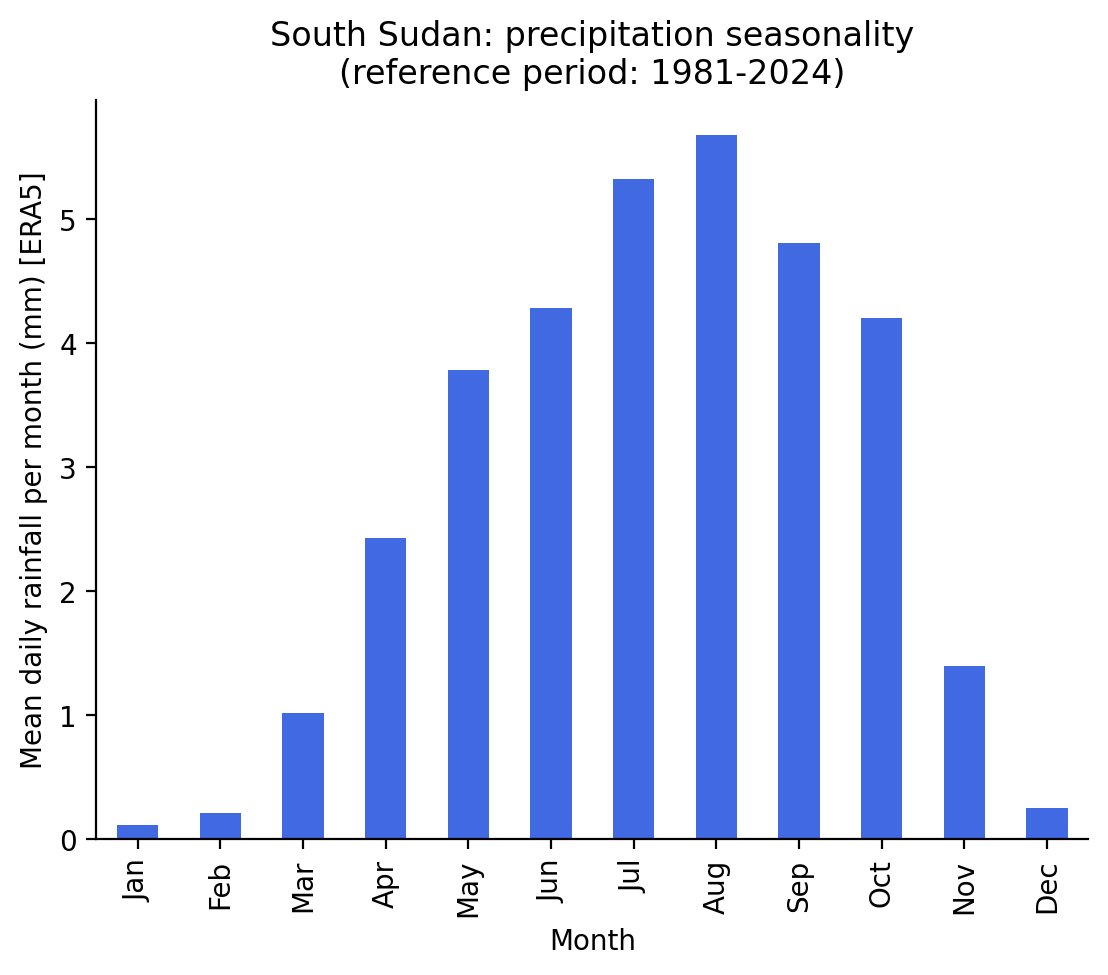

In [12]:
fig, ax = plt.subplots(dpi=200)
df_era5_monthly.plot.bar(
    x="valid_month_str", y="mean", legend=False, ax=ax, color="royalblue"
)
ax.set_xlabel("Month")
ax.set_ylabel("Mean daily rainfall per month (mm) [ERA5]")
ax.set_title(
    f"{adm_name_str}: precipitation seasonality\n"
    f"(reference period: {df_era5_full['valid_date'].dt.year.min()}-{max_full_year})"
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

### EM-DAT

In [13]:
df_emdat = emdat.load_emdat_yearly(
    iso3=iso3, disaster_type=disaster_type, col=impact_col
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### CERF

In [14]:
df_cerf = cerf.load_cerf_yearly(emergency=disaster_type, iso3=iso3)

### Combine datasets

In [16]:
df_compare = (
    df_seas5.merge(
        df_era5, on="year", how="outer", suffixes=("_seas5", "_era5")
    )
    .merge(df_emdat, how="outer")
    .merge(df_cerf, how="outer")
)

In [17]:
df_compare.loc[df_compare["year"] < 2006, "allocation"] = "pre-CERF"

In [18]:
df_compare

,year,mean_seas5,mean_detrended_seas5,mean_era5,mean_detrended_era5,Total Affected,Amount in US$,allocation
0,1981,6.368746,6.708666,6.370742,5.535743,NaN,NaN,pre-CERF
1,1982,5.503742,5.827851,5.253522,4.457360,NaN,NaN,pre-CERF
2,1983,5.300693,5.608992,6.121003,5.363678,NaN,NaN,pre-CERF
3,1984,5.864295,6.156784,5.780768,5.062280,NaN,NaN,pre-CERF
4,1985,6.494820,6.771499,6.582485,5.902835,NaN,NaN,pre-CERF
5,1986,5.948166,6.209034,5.688345,5.047531,NaN,NaN,pre-CERF
6,1987,5.368880,5.613938,5.064137,4.462160,NaN,NaN,pre-CERF
7,1988,6.449613,6.678861,6.550306,5.987167,NaN,NaN,pre-CERF
8,1989,6.186039,6.399476,5.619099,5.094798,NaN,NaN,pre-CERF
9,1990,6.164523,6.362151,5.567138,5.081673,NaN,NaN,pre-CERF


## Plotting

In [19]:
col_to_label = {
    "mean_detrended_seas5": "Forecasted mean daily rainfall, detrended, "
    f"issued {issued_mo_str} (mm) [SEAS5]",
    "mean_detrended_era5": "Observed mean daily rainfall, detrended (mm) [ERA5]",
}

In [126]:
high_color = "royalblue"
current_color = "mediumorchid"
cerf_color_mapping = {
    "Yes": "crimson",
    "No": "k",
    "pre-CERF": "gray",
    np.nan: "k",
}

In [130]:
def plot_comparison(
    df,
    xcol: str,
    ycol: str,
    colorcol: str = None,
    sizecol: str = None,
    rotation: int = 0,
    min_year: int = None,
    title: str = None,
    show_terciles: bool = True,
):
    fig, ax = plt.subplots(dpi=200, figsize=(7, 7))

    if min_year is not None:
        df = df[df["year"] >= min_year]
    df = df.copy()

    xmax, ymax = df[[xcol, ycol]].max()
    xmin, ymin = df[[xcol, ycol]].min()
    padding = 0.1
    xrange = xmax - xmin
    yrange = ymax - ymin
    xlim = (xmin - padding * xrange, xmax + padding * xrange)
    ylim = (ymin - padding * yrange, ymax + padding * yrange)

    if show_terciles:
        df_ref = df.dropna(subset=[xcol, ycol])
        ref_min_year = df_ref["year"].min()
        ref_max_year = df_ref["year"].max()
        x_thresh, y_thresh = df_ref[[xcol, ycol]].quantile(2 / 3)
        ax.axvspan(
            xmin=x_thresh,
            xmax=xlim[1],
            facecolor=high_color,
            alpha=0.1,
            zorder=-1,
        )
        ax.axhspan(
            ymin=y_thresh,
            ymax=ylim[1],
            facecolor=high_color,
            alpha=0.1,
            zorder=-1,
        )

    max_bubble_size = 2000
    if sizecol is None:
        sizes = np.full(len(df), 0)
        max_size_value = None
    else:
        sizes = df[sizecol].fillna(0) / df[sizecol].max() * max_bubble_size
        max_size_value = df[sizecol].max()

    if colorcol is None:
        df["color"] = "k"
    else:
        df["color"] = df[colorcol].map(cerf_color_mapping)

    scatter = ax.scatter(
        df[xcol],
        df[ycol],
        s=sizes,
        c=df["color"],
        alpha=0.3,
        edgecolor="none",
        zorder=2,
    )

    for year, row in df.set_index("year").iterrows():
        ax.annotate(
            str(year),
            (row[xcol], row[ycol]),
            fontsize=8,
            ha="center",
            va="center",
            color=row["color"],
            rotation=rotation,
            zorder=3,
        )

    if "seas5" in xcol:
        current_val = df.set_index("year").loc[2025][xcol]
        ax.axvline(
            current_val,
            color=current_color,
            linestyle="--",
            zorder=-1,
        )
        ax.annotate(
            " 2025 forecast",
            (current_val, ylim[0]),
            rotation=90,
            va="bottom",
            ha="right",
            color=current_color,
            zorder=-1,
            fontstyle="italic",
        )

    ax.set_xlabel(col_to_label.get(xcol, xcol))
    ax.set_ylabel(col_to_label.get(ycol, ycol))

    if title is not None:
        ax.set_title(title)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # legend
    legend_x = xlim[0] + xrange * 0.18

    def get_legend_y(row_num):
        return ylim[1] - yrange * 0.04 - yrange * row_num * 0.03

    ax.annotate(
        "CERF allocation:",
        (legend_x, get_legend_y(0)),
        va="top",
        fontstyle="italic",
        fontsize=6,
    )
    for i, (label, color) in enumerate(cerf_color_mapping.items()):
        if str(label) == "nan":
            continue
        ax.annotate(
            label,
            (legend_x, get_legend_y(i + 1)),
            va="top",
            color=color,
            fontsize=6,
        )
    if sizecol is not None:
        x_legend_bubble = legend_x - xrange * 0.08
        y_legend_bubble = get_legend_y(2)
        ax.scatter(
            [x_legend_bubble],
            [y_legend_bubble],
            s=[max_bubble_size],
            facecolor="none",
            edgecolor="k",
            linewidth=0.5,
        )
        ax.annotate(
            f"{sizecol}:\n{max_size_value:,.0f}",
            (x_legend_bubble, y_legend_bubble),
            ha="center",
            va="center",
            fontstyle="italic",
            fontsize=6,
        )

    rect = mpatches.Rectangle(
        (legend_x - xrange * 0.16, get_legend_y(4.7)),
        xrange * 0.32,
        yrange * 0.16,
        linewidth=0.5,
        color="white",
        zorder=0,
        alpha=0.5,
    )

    # Add to axes
    ax.add_patch(rect)

    return fig, ax

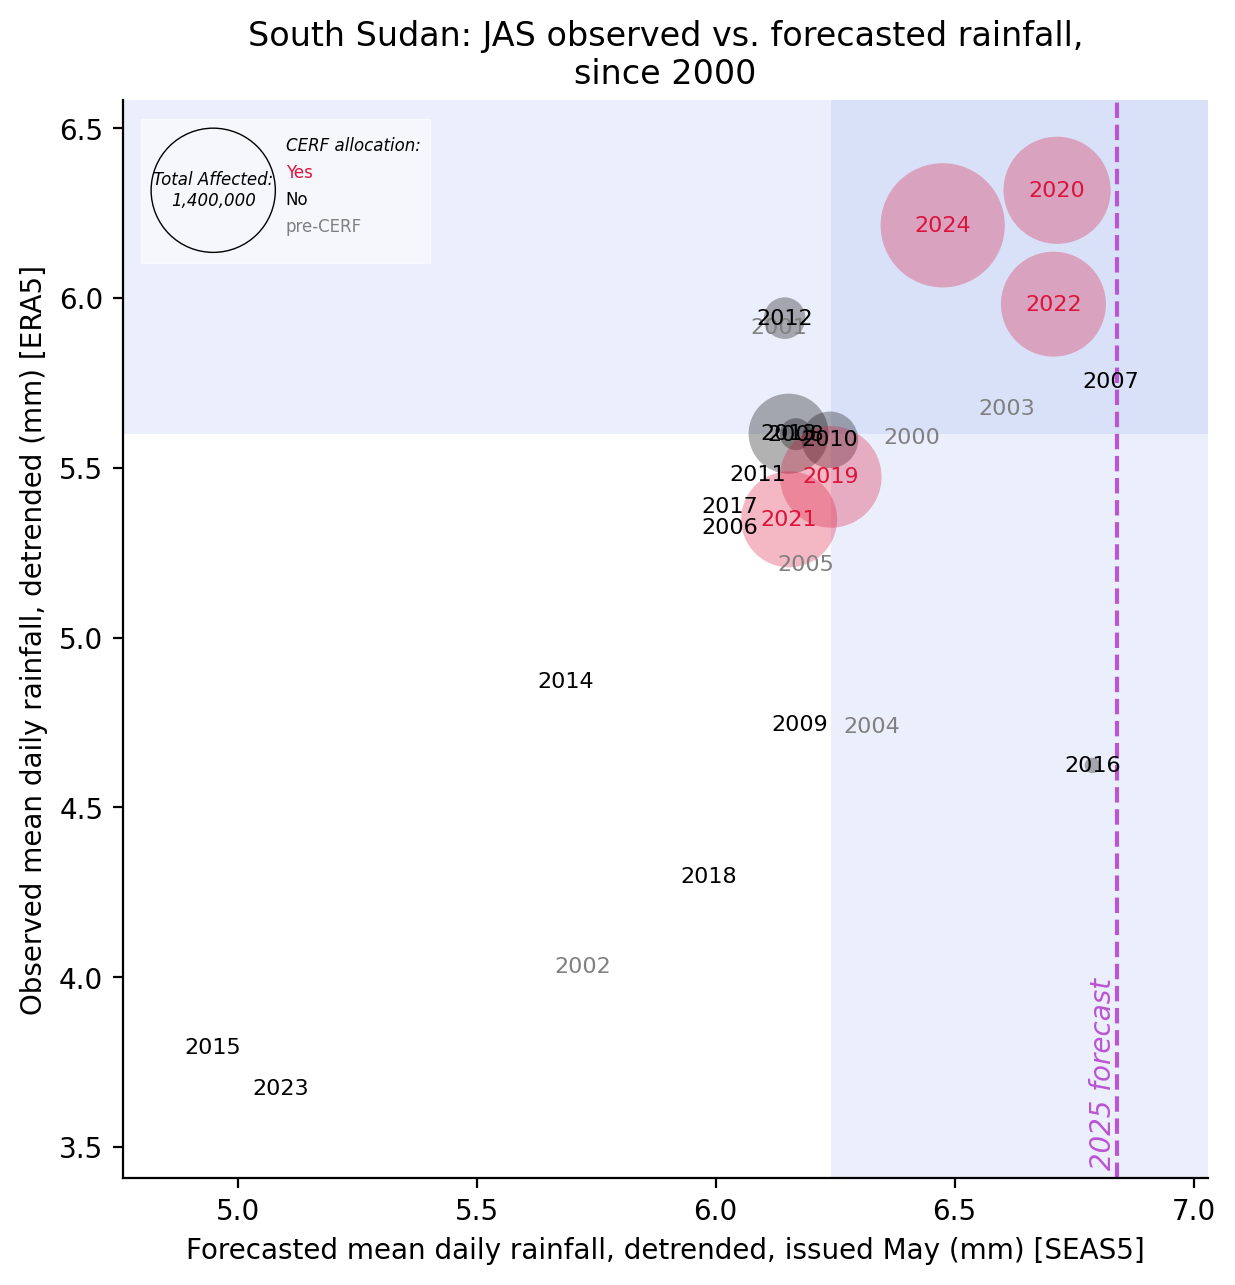

In [131]:
min_year = 2000
fig, ax = plot_comparison(
    df_compare,
    xcol="mean_detrended_seas5",
    ycol="mean_detrended_era5",
    sizecol="Total Affected",
    colorcol="allocation",
    title=f"{adm_name}: {valid_mo_str} observed vs. forecasted rainfall,\n"
    f"since {min_year}",
    min_year=min_year,
)